# racetraQ 02 — Q-learning from scratch

In [notebook 01](01_the_racing_env.ipynb) we saw the racing environment: 4
observation features, 4 discrete actions, progress-based reward. Now we make an
agent *learn* to drive — with a classical neural network so small it will be
directly comparable to a 4-qubit quantum circuit later.

## The 60-second theory

Driving is a **Markov decision process**: at each step the agent sees a state
$s$, picks an action $a$, gets a reward $r$ and a next state $s'$. The
**Q-function** $Q(s, a)$ is the total discounted reward you can still collect
by taking action $a$ in state $s$ and playing well afterwards. The optimal
Q-function satisfies the Bellman equation

$$Q^*(s, a) = \mathbb{E}\left[\, r + \gamma \max_{a'} Q^*(s', a') \,\right],$$

and once you have it, the optimal policy is trivial: pick
$\arg\max_a Q(s, a)$.

Two warm-ups come first: a Q-function small enough to be a table, and a
five-minute tour of the neural network that replaces the table. Then deep
Q-learning puts the two together.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import racetraq  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/racetraQ

import matplotlib.pyplot as plt
import numpy as np

## Warm-up 1: a Q-table

When there are only a few states, $Q$ can simply be a table: one number per
state and action. **Tabular Q-learning** fills it in by trial and error.
After every step it nudges one entry towards the Bellman target:

$$Q(s, a) \leftarrow Q(s, a) + \alpha\,\big[\, r + \gamma \max_{a'} Q(s', a') - Q(s, a) \,\big],$$

where $\alpha$ is the step size and the bracket is the **TD error** (temporal
difference: how much better or worse the step went than the table expected).

A toy version of the racetraQ lesson from [notebook 01](01_the_racing_env.ipynb).
A car drives down a straight of 9 cells (0 to 8) towards a hairpin. Each step
it either keeps the **throttle** on (moves 2 cells) or **brakes** (moves 1
cell). Every step costs −1 (the clock runs). Entering the hairpin (cell 9)
under braking earns +10 and ends the episode; arriving under throttle, or
overshooting, is a crash: −10 and the end. The table has 9 × 2 = 18 entries.

In [2]:
CELLS = 9                      # cells 0..8; the hairpin is cell 9
THROTTLE, BRAKE = 0, 1


def corridor_step(cell, action):
    # (next cell, reward, episode over) for the toy straight
    nxt = cell + (2 if action == THROTTLE else 1)
    if nxt < CELLS:
        return nxt, -1.0, False
    if nxt == CELLS and action == BRAKE:
        return nxt, 10.0, True        # made the hairpin
    return nxt, -10.0, True           # too fast: off the track


def tabular_q_learning(episodes=300, alpha=0.5, gamma=0.98, seed=0):
    rng = np.random.default_rng(seed)
    table = np.zeros((CELLS, 2))
    for episode in range(episodes):
        epsilon = max(0.05, 1.0 - episode / 200)           # explore a lot at first
        cell, done = 0, False
        while not done:
            explore = rng.random() < epsilon
            action = int(rng.integers(2)) if explore else int(table[cell].argmax())
            nxt, reward, done = corridor_step(cell, action)
            target = reward if done else reward + gamma * table[nxt].max()
            table[cell, action] += alpha * (target - table[cell, action])   # the update rule
            cell = nxt
    return table


table = tabular_q_learning()
print("cell          " + "".join(f"{c:>7}" for c in range(CELLS)))
print("Q(throttle)   " + "".join(f"{v:>7.2f}" for v in table[:, THROTTLE]))
print("Q(brake)      " + "".join(f"{v:>7.2f}" for v in table[:, BRAKE]))
print("greedy action " + "".join(f"{'TB'[a]:>7}" for a in table.argmax(axis=1)))

cell, route = 0, []
while cell < CELLS:
    action = int(table[cell].argmax())
    route.append(f"{cell}{'T' if action == THROTTLE else 'B'}")
    cell, _, _ = corridor_step(cell, action)
print("greedy drive from cell 0:", " -> ".join(route), "-> hairpin")

cell                0      1      2      3      4      5      6      7      8
Q(throttle)      5.34   5.33   6.47   6.47   7.62   7.62   8.80 -10.00 -10.00
Q(brake)         4.24   5.34   5.34   6.47   6.47   7.62   7.62   8.80  10.00
greedy action       T      B      T      T      T      T      T      B      B
greedy drive from cell 0: 0T -> 2T -> 4T -> 6T -> 8B -> hairpin


Read the table along the greedy drive: throttle from cell 0 to cell 8, brake
into the hairpin. At cells 7 and 8 the throttle entry is −10: the table has
learned that speed there ends in a crash. (Odd cells are reached only by
braking early, so the greedy drive never visits them; there the two actions
are worth about the same.) Nobody wrote "brake before the hairpin" into the
code. It came out of the rewards.

A table works because there are only 9 states. The race car's state is
four *continuous* sensor values. A table would need bins: 10 bins per sensor
already make $10^4$ states × 4 actions = 40,000 entries, most of which a car
would never visit, and nothing learned in one bin would carry over to its
neighbour. So the table is replaced by a function with a few dozen
adjustable numbers, which shares what it learns between similar states.

## Warm-up 2: a neural network in five minutes

- A **neuron** takes numbers in, multiplies each by a **weight**, adds them
  up with a **bias**, and passes the sum through an **activation function**.
  racetraQ uses $\tanh$, which squashes any number into $(-1, 1)$. Without
  the activation, stacking neurons would only ever give a straight-line
  (linear) function.
- A **layer** is many neurons reading the same inputs. racetraQ's network has
  one hidden layer of 8 tanh neurons reading the 4 sensors, and an output
  layer of 4 plain (linear) neurons, one Q-value per action:
  $4 \times 8 + 8 + 8 \times 4 + 4 = 76$ weights and biases.
- The **loss** says how wrong the network is: here the squared difference
  between its output and a target, averaged.
- **Gradient descent** changes every weight a small step against the
  gradient (the slope) of the loss: weight ← weight − learning rate ×
  slope. The **learning rate** sets the step size. Too small and learning
  crawls; too large and the steps overshoot and the loss explodes.
- **Backpropagation** computes all the slopes at once with the chain rule,
  in one backward pass from the loss to the first layer. racetraQ's
  `MLPQFunction.grad_selected` does exactly that in a dozen lines of numpy.

The cell fits a 1-input version of that network (1 → 8 tanh → 1, 25
weights) to a wiggly curve with plain gradient descent, at three learning
rates.

learning rate 0.03  loss 0.1428 at the start, 0.0606 after 3000 steps


learning rate 0.3   loss 0.1428 at the start, 0.0017 after 3000 steps
learning rate 3.0   loss 0.1428 at the start, blew up (inf/nan) after 113 steps


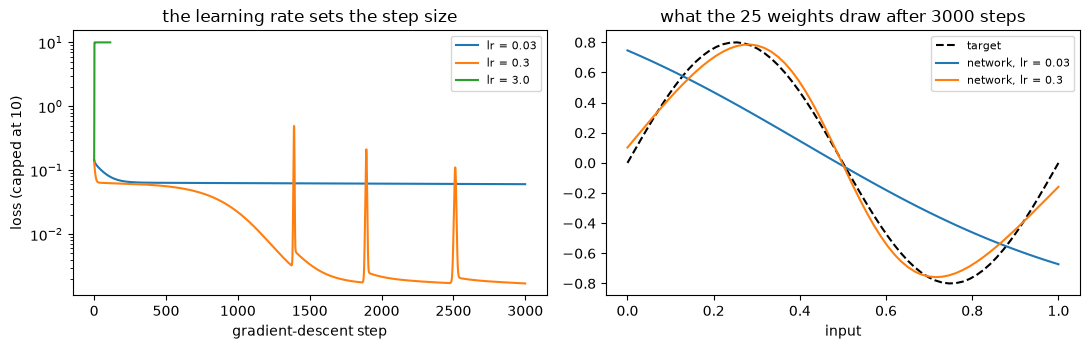

In [3]:
from racetraq.agents.classical import MLPQFunction

x = np.linspace(0.0, 1.0, 64)[:, None]          # 64 inputs
y = 0.8 * np.sin(2 * np.pi * x[:, 0])            # the curve to learn
steps = 3000
fits, curves = {}, {}
for lr in (0.03, 0.3, 3.0):
    net = MLPQFunction(n_features=1, hidden=8, n_actions=1, seed=0)
    losses = []
    with np.errstate(over="ignore", invalid="ignore"):    # the largest rate blows up
        for _ in range(steps):
            error = net.q_values(x)[:, 0] - y
            losses.append(0.5 * np.mean(error**2))        # the loss
            if not np.isfinite(losses[-1]):
                break
            # backprop: gradient of the loss wrt all 25 weights, in one call
            grad = net.grad_selected(x, np.zeros(len(x), dtype=int), error / len(x))
            net.set_params(net.get_params() - lr * grad)  # one gradient-descent step
    curves[lr] = losses
    fits[lr] = net.q_values(x)[:, 0] if np.isfinite(losses[-1]) else None
    end = f"{losses[-1]:.4f} after {steps} steps" if np.isfinite(losses[-1]) else \
        f"blew up (inf/nan) after {len(losses)} steps"
    print(f"learning rate {lr:<5} loss {losses[0]:.4f} at the start, {end}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
for lr, losses in curves.items():
    ax1.plot(np.minimum(losses, 10.0), label=f"lr = {lr}")
ax1.set(yscale="log", xlabel="gradient-descent step", ylabel="loss (capped at 10)",
        title="the learning rate sets the step size")
ax1.legend(fontsize=8)
ax2.plot(x[:, 0], y, "k--", label="target")
for lr, fit in fits.items():
    if fit is not None:
        ax2.plot(x[:, 0], fit, label=f"network, lr = {lr}")
ax2.set(xlabel="input", title=f"what the 25 weights draw after {steps} steps")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

The small rate is still creeping down at the end; the middle one fits the
curve; the large one overshoots, and its loss grows until the numbers
overflow. Q-learning adds a twist: the target $r + \gamma \max_{a'} Q(s', a')$
is computed from the network itself, so it moves while the network learns.
That is what the tricks below are for.

## Deep Q-learning

**Deep Q-learning (DQN)** joins the two warm-ups. It keeps the Bellman target
of the Q-table, $r + \gamma \max_{a'} Q(s', a')$, but replaces the table by a
network: the TD error becomes a loss, and gradient descent moves *all* the
weights a little towards the target, with three
stabilizing tricks used here:

- **replay buffer** — train on random past transitions, not just the latest ones
- **target network** — a slow-moving copy of the parameters computes the target
  $r + \gamma\, Q_\mathrm{target}(s', a^*)$, with the online network choosing
  $a^*$ (**double DQN**)
- **$\varepsilon$-greedy exploration** — act randomly with probability
  $\varepsilon$, annealed from 1.0 to 0.05

One detail concerns how an episode *ends*. Leaving the track is a real
terminal state: nothing more can be earned, so the target is just $r$.
Running into the 60 s time limit is not — the car is still on track and
would have kept collecting reward. That ending is a *truncation*, and the
target keeps bootstrapping from the state the car was in
(`bootstrap_truncation = true` in the default config; with `false` the
time limit is treated like a crash without the penalty).

The whole loop is a few hundred lines of numpy in
`racetraq.agents.training.dqn` — no deep-learning framework. That matters
later: the same loop will train the quantum circuit unchanged.

## The classical Q-function

`MLPQFunction` is a single-hidden-layer network: 4 features → 8 tanh units → 4
Q-values, i.e. **76 parameters** in one flat vector. Every Q-function backend
in racetraQ implements the same 4-method protocol (`q_values`,
`grad_selected`, `get_params`, `set_params`), which is all the trainer needs.

In [4]:
from racetraq.agents.classical import MLPQFunction

qfunc = MLPQFunction(n_features=4, hidden=8, n_actions=4, seed=0)
print(f"parameters: {qfunc.n_params}")
print("Q-values for one observation:", np.round(qfunc.q_values([[0.5, 1.0, 0.5, 0.3]]), 3))

parameters: 76
Q-values for one observation: [[-0.388 -0.571 -0.268  0.271]]


## Train it

300 episodes on the oval with the repository's default `[training]` recipe:
8 vectorized cars collecting experience in parallel, one gradient update per
environment decision. On a laptop this takes seconds to a few tens of seconds,
depending on what else the machine is doing (the cell prints it).
The `CleanLapMonitor` wrapper records the first episode in which a full lap
was driven without leaving the track. This is **one run with one seed** — a
demonstration of the loop, not a measurement.

In [5]:
import time

from racetraq.agents.training import DQNTrainer
from racetraq.config import load_config
from racetraq.env.racing_env import RacingEnv
from racetraq.env.track import Track
from racetraq.train_headless import CleanLapMonitor

config = load_config()
training_cfg = dict(config["training"])
training_cfg["seed"] = 0

track = Track.load("oval")
env = RacingEnv(track, config, n_envs=training_cfg["n_parallel_envs"], seed=0)
monitor = CleanLapMonitor(env)
qfunc = MLPQFunction(n_features=env.n_features, hidden=8, n_actions=4, seed=0)
trainer = DQNTrainer(qfunc, monitor, training_cfg, rng=np.random.default_rng(0))

print(f"recipe: gamma {training_cfg['gamma']}, lr {training_cfg['lr']}, epsilon "
      f"{training_cfg['epsilon_start']} -> {training_cfg['epsilon_end']} over "
      f"{training_cfg['epsilon_decay_episodes']} episodes, "
      f"bootstrap_truncation {training_cfg.get('bootstrap_truncation', False)}")
t0 = time.perf_counter()
history = trainer.train(episodes=300)
print(f"trained 300 episodes in {time.perf_counter() - t0:.1f} s")
print(f"first clean lap: episode {monitor.first_clean_episode} "
      f"(after {monitor.first_clean_wall_s:.1f} s of training)")
print(f"best lap during training: {monitor.best_lap_s:.1f} s")

recipe: gamma 0.98, lr 0.01, epsilon 1.0 -> 0.05 over 250 episodes, bootstrap_truncation True


trained 300 episodes in 31.1 s
first clean lap: episode 165 (after 2.7 s of training)
best lap during training: 12.7 s


## The learning curve

Per-episode returns are noisy (spawn jitter, exploration), so we overlay a
rolling mean. Reading the y-axis: the dotted line is what one clean lap is
worth — the track length in progress reward plus the checkpoint and lap
bonuses — so returns of several times that mean several laps per episode.
Dots far *below* zero are real, too: progress is signed, so a car that gets
turned around and keeps driving earns negative reward for as long as it stays
on track — up to a whole episode of laps the wrong way round (the cell prints
the lowest return).

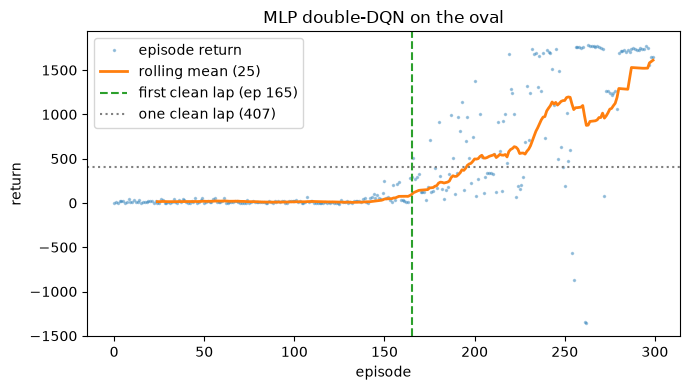

one clean lap of the oval is worth 407; mean return of the last 25 episodes: 1612
lowest episode return: -1351 (one lap of progress the wrong way: -337)


In [6]:
returns = np.array(history["episode_returns"])
window = 25
smooth = np.convolve(returns, np.ones(window) / window, mode="valid")

reward_cfg = config["reward"]
lap_reward = (reward_cfg["progress_scale"] * track.total_length
              + reward_cfg["checkpoint_bonus"] * len(track.checkpoints)
              + reward_cfg["lap_bonus"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(returns, ".", ms=3, alpha=0.35, label="episode return")
ax.plot(np.arange(window - 1, len(returns)), smooth, lw=2,
        label=f"rolling mean ({window})")
if monitor.first_clean_episode:
    ax.axvline(monitor.first_clean_episode, color="tab:green", ls="--",
               label=f"first clean lap (ep {monitor.first_clean_episode})")
ax.axhline(lap_reward, color="0.5", ls=":", label=f"one clean lap ({lap_reward:.0f})")
ax.set(xlabel="episode", ylabel="return", title="MLP double-DQN on the oval")
ax.legend()
plt.tight_layout()
plt.show()
print(f"one clean lap of the oval is worth {lap_reward:.0f}; mean return of the last "
      f"{window} episodes: {returns[-window:].mean():.0f}")
print(f"lowest episode return: {returns.min():.0f} (one lap of progress the wrong way: "
      f"{-reward_cfg['progress_scale'] * track.total_length:.0f})")

## Watch what it learned: greedy rollout

Set $\varepsilon = 0$ and let the network — with the parameters it has
after the last update — drive a fresh car from a standing start. The
trajectory is colored by speed. Look at the line it takes through the two
turns, and at whether it ever slows down for them (the cell counts its brake
decisions). The cell also prints the radius of the oval's tightest turn next
to the car's turning radius at top speed, from the physics of
[notebook 01](01_the_racing_env.ipynb): where the first is the larger, a
driver can stay flat out all the way round — the brake is for the hairpins of
`gp` and `combo`.

tightest turn of the oval: centerline radius 24.5 units; turning radius at top speed: 15.1 units


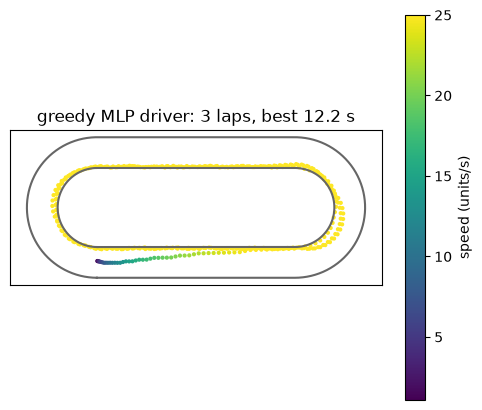

greedy rollout: 3 laps, best lap 12.2 s; brake decisions: 0 of 400


In [7]:
from racetraq.env.car import CarPhysics


def draw_track(ax, track):
    cl, hw = track.centerline, track.half_width
    for sign in (+1.0, -1.0):
        b = cl + sign * hw * track.normals
        b = np.vstack([b, b[:1]])
        ax.plot(b[:, 0], b[:, 1], color="0.4", lw=1.5)
    ax.set_aspect("equal")
    ax.set_xticks([]), ax.set_yticks([])


car = CarPhysics(config["physics"])
r_top = car.v_max / (car.k_steer * car.steer_falloff(np.array([car.v_max]))[0])
print(f"tightest turn of the oval: centerline radius {1 / track.max_abs_curvature:.1f} units; "
      f"turning radius at top speed: {r_top:.1f} units")

eval_env = RacingEnv(track, config, n_envs=1, seed=123)
obs = eval_env.reset()
xy, speed, taken, best_lap, laps = [], [], [], np.inf, 0
for _ in range(400):
    actions = np.argmax(qfunc.q_values(obs), axis=1)  # greedy
    obs, reward, done, info = eval_env.step(actions)
    taken.append(int(actions[0]))
    xy.append(eval_env.state[0, :2].copy())
    speed.append(eval_env.state[0, 3])
    if not np.isnan(info["last_lap_time"][0]):
        best_lap = min(best_lap, info["last_lap_time"][0])
    laps = max(laps, info["lap"][0])
    if done[0]:
        break
xy = np.array(xy)

fig, ax = plt.subplots(figsize=(6, 5))
draw_track(ax, track)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=speed, s=4, cmap="viridis")
fig.colorbar(sc, ax=ax, label="speed (units/s)")
ax.set_title(f"greedy MLP driver: {laps} laps, best {best_lap:.1f} s")
plt.show()
print(f"greedy rollout: {laps} laps, best lap {best_lap:.1f} s; "
      f"brake decisions: {taken.count(3)} of {len(taken)}")


Read the result off the outputs above: the episode of the first clean lap, and
what the final parameters do when they drive greedily. If the rollout
completed laps, a 76-parameter network has learned to lap the oval in seconds
of wall-clock time.

Keep in mind what this was: one seed, one start position, and the parameters
of the *last* update. A DQN's greedy policy keeps changing while it trains, so
the last parameters are not necessarily the best ones the run has seen — with
a different `seed` this same rollout can end without a lap even though the
run drove clean laps during training. That is why the training tools evaluate
greedy snapshots along the way and keep the best one, and why
[notebook 04](04_training_the_quantum_driver.ipynb) compares agents over many
seeds instead of one.

## From table to network to circuit

The key design point of racetraQ: `DQNTrainer` only ever talks to the
Q-function through `q_values` / `grad_selected` / `get_params` / `set_params`.
Anything implementing those four methods can drive — including a quantum
circuit. The whole series is one line:

| | Q-table (warm-up 1) | Q-network (this notebook) | Q-circuit ([notebook 03](03_quantum_circuits_as_q_functions.ipynb)) |
|---|---|---|---|
| input | one of a few discrete states | 4 sensor values | 4 sensor values |
| what is learned | one number per state and action (18 here) | 76 weights and biases | 56 rotation angles, input scales and output weights |
| one update | Bellman step on one entry | gradient step on all weights (backprop) | gradient step on all angles (adjoint method) |
| generalises to unseen states | no | yes | yes |

## Exercises

Each exercise asks you to **predict first**, then check. Write your
prediction down before you open the solution. The solution cells are
collapsed in JupyterLab; they run like any other cell.

**Exercise 1 — Bellman by hand.** In the corridor, every step costs −1, the
hairpin pays +10, and $\gamma = 0.98$. Without looking at the table, what
should $Q(\text{cell } 6, \text{throttle})$ be once learning has converged?
And $Q(\text{cell } 7, \text{throttle})$?

<details>
<summary>Solution 1</summary>

From cell 6, throttle reaches cell 8 (reward −1). From 8 the best move is to
brake into the hairpin (+10). So
$Q(6, \text{throttle}) = -1 + 0.98 \times 10 = 8.8$. From cell 7, throttle
arrives at the hairpin at speed: a crash, −10, and nothing after it, so
$Q(7, \text{throttle}) = -10$. The cell below reads both off the learned
table.

</details>

In [8]:
# Solution 1
print(f"Q(6, throttle) = {table[6, THROTTLE]:.2f}   (by hand: -1 + 0.98 * 10 = 8.80)")
print(f"Q(7, throttle) = {table[7, THROTTLE]:.2f}   (by hand: -10)")

Q(6, throttle) = 8.80   (by hand: -1 + 0.98 * 10 = 8.80)
Q(7, throttle) = -10.00   (by hand: -10)


**Exercise 2 — a shorter horizon.** The discount $\gamma$ says how much the
agent cares about later rewards. Roughly, it looks $1/(1-\gamma)$ decisions
ahead: 50 decisions (5 s of driving) at the default $\gamma = 0.98$. Train
the MLP again with $\gamma = 0.9$ (10 decisions, 1 s). Predict: will it
still lap the oval? And will its Q-values be larger, smaller or about the
same as those of the network trained above, at the same observation?
(Hint: at top speed the car gains about 2.5 units of track per decision.)

<details>
<summary>Solution 2</summary>

A Q-value is roughly reward per decision × horizon. At top speed that is
about $2.5 \times 50 \approx 125$ for $\gamma = 0.98$ and
$2.5 \times 10 = 25$ for $\gamma = 0.9$, so the Q-values should come out
several times smaller. The default network after 300 episodes is still below
its ceiling, so the ratio is smaller than 5. The oval needs no braking and
progress is rewarded at once, so a 1-second horizon can be enough to lap.
On a hairpin track it is not obviously enough: the payoff of braking comes
seconds later. This is one seed, so treat the lap result as an anecdote.

</details>

In [9]:
# Solution 2 (about 15 s)
def train_variant(**changes):
    cfg = dict(training_cfg, **changes)
    env = RacingEnv(track, config, n_envs=cfg["n_parallel_envs"], seed=0)
    lap_monitor = CleanLapMonitor(env)
    net = MLPQFunction(n_features=env.n_features, hidden=8, n_actions=4, seed=0)
    hist = DQNTrainer(net, lap_monitor, cfg, rng=np.random.default_rng(0)).train(episodes=300)
    return net, lap_monitor, np.array(hist["episode_returns"])


probe = np.array([[0.5, 1.0, 0.5, 0.8]])    # centred on a straight, at speed
net_09, monitor_09, returns_09 = train_variant(gamma=0.9)
print(f"Q-values at {probe[0].tolist()}:")
print(f"  gamma 0.98 (trained above): {np.round(qfunc.q_values(probe)[0], 1)}")
print(f"  gamma 0.9:                  {np.round(net_09.q_values(probe)[0], 1)}")
print(f"first clean lap with gamma 0.9: episode {monitor_09.first_clean_episode}; "
      f"mean return of the last 25 episodes {returns_09[-25:].mean():.0f} "
      f"(gamma 0.98: {returns[-25:].mean():.0f})")

Q-values at [0.5, 1.0, 0.5, 0.8]:
  gamma 0.98 (trained above): [68.1 67.3 68.8 66.2]
  gamma 0.9:                  [25.  24.2 24.1 22.6]
first clean lap with gamma 0.9: episode 152; mean return of the last 25 episodes 1401 (gamma 0.98: 1612)


**Exercise 3 — a learning rate ten times larger.** The DQN uses Adam with
`lr = 0.01`. Set it to 0.1. Predict, with warm-up 2 in mind: does the
network learn faster, the same, or worse?

<details>
<summary>Solution 3</summary>

Worse. As in warm-up 2, a step that is too large overshoots. Here it is worse
than in a fixed regression: every overshoot also moves the targets, which are
computed from the same network. Expect the returns of the last episodes to be
far below those of the default run. Again one seed: run it with a few others
(`seed=1`, `2`, …) before you believe it. A related experiment to try on your
own: `target_sync_every=1` removes the slow target copy, so the target moves
with every update.

</details>

In [10]:
# Solution 3 (about 10 s)
net_lr, monitor_lr, returns_lr = train_variant(lr=0.1)
print(f"mean return of the last 25 episodes: lr 0.1 -> {returns_lr[-25:].mean():.0f}, "
      f"lr 0.01 (trained above) -> {returns[-25:].mean():.0f}")
print(f"first clean lap with lr 0.1: episode {monitor_lr.first_clean_episode}")

mean return of the last 25 episodes: lr 0.1 -> 236, lr 0.01 (trained above) -> 1612
first clean lap with lr 0.1: episode 194


## Checkpoint

1. In words: what does $Q(s, a)$ measure?
2. Why does the race car need a network (or a circuit) instead of a Q-table?
3. What does the learning rate control, and what happens when it is too
   large?

<details>
<summary>Answers</summary>

1. The total discounted reward the agent can still expect if it takes action
   $a$ in state $s$ and plays well afterwards. The greedy policy picks the
   action with the largest $Q$.
2. Its state is four continuous numbers. A table needs discrete states; with
   fine bins it gets huge and learns nothing about bins it has not visited.
   A network has a fixed number of weights (76) and shares what it learns
   between similar states.
3. The size of each gradient-descent step. Too large and the steps
   overshoot: the loss grows instead of shrinking (warm-up 2, exercise 3).

</details>

**Next:** [03 — Quantum circuits as Q-functions](03_quantum_circuits_as_q_functions.ipynb)
replaces the network with a quantum circuit — the last column of the table
above. New to qubits? [00 — Qubits for drivers](00_qubits_for_drivers.ipynb)
is a 15-minute primer.